<a href="https://colab.research.google.com/github/cvinushareddy/Data-science-projects/blob/main/WEEK_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

C VINUSHA REDDY

1CR22IS036

#  Problem Statement

Customer churn is a major concern for businesses, especially in industries like telecom, banking, and SaaS. Losing customers leads to **revenue loss** and **higher acquisition costs**.  

In this project, the goal is to build a **Machine Learning classification model** that predicts whether a customer will leave the company (**Churn: Yes/No**) based on features such as:

- Customer Age  
- Gender  
- Tenure  
- Monthly Charges  
- Total Charges  
- Contract Type  
- Payment Method  
- Internet Service  
- Tech Support  
- Online Security  
- Customer Support Calls  

Students are required to **analyze the dataset, preprocess the data, perform feature engineering, train multiple classification models**, and **evaluate their performance** to identify the best model for predicting customer churn.

---

#  Objective

The objectives of this task are to:

1. **Understand and explore the customer dataset** → Identify patterns, distributions, and data quality issues.  
2. **Perform data preprocessing** → Handle missing values, duplicates, and outliers.  
3. **Conduct Exploratory Data Analysis (EDA)** → Visualize relationships between features and churn.  
4. **Apply encoding and feature scaling** → Convert categorical variables and normalize numerical features.  
5. **Train multiple classification algorithms** → Logistic Regression, KNN, Decision Tree, Random Forest, SVC, Gradient Boosting, XGBoost.  
6. **Evaluate models using classification metrics** → Accuracy, Precision, Recall, F1 Score, ROC-AUC, Confusion Matrix.  
7. **Perform cross-validation and hyperparameter tuning** → Optimize model performance.  
8. **Select the best-performing model** → Based on metrics and business applicability.

###1. Import Libraries

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

###2. Load Dataset

In [60]:
data = pd.read_csv('telecom_churn_data.csv')

###3. Check Dataset

In [61]:
data.shape
data.columns
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7038 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7041 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7041.000000
mean,0.162147,32.371149,64.749581
std,0.368612,24.559481,30.085731
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#  Understanding Variables

- **CustomerID** – Unique ID assigned to each customer.  
- **Gender** – Gender of the customer (Male, Female).  
- **SeniorCitizen** – Whether the customer is a senior citizen (1 = Yes, 0 = No).  
- **Partner** – Whether the customer has a partner (Yes/No).  
- **Dependents** – Whether the customer has dependents (Yes/No).  
- **Tenure** – Number of months the customer has stayed with the company.  

- **PhoneService** – Whether the customer has phone service (Yes/No).  
- **MultipleLines** – Whether the customer has multiple phone lines (Yes, No, No phone service).  
- **InternetService** – Type of internet service (DSL, Fiber optic, No).  
- **OnlineSecurity** – Whether online security is enabled (Yes/No).  
- **OnlineBackup** – Whether online backup service is enabled (Yes/No).  
- **DeviceProtection** – Whether device protection is enabled (Yes/No).  
- **TechSupport** – Whether tech support is available (Yes/No).  
- **StreamingTV** – Whether the customer streams TV (Yes/No).  
- **StreamingMovies** – Whether the customer streams movies (Yes/No).  

- **Contract** – Type of contract (Month-to-month, One year, Two year).  
- **PaperlessBilling** – Whether paperless billing is used (Yes/No).  
- **PaymentMethod** – Payment method used (Electronic check, Mailed check, Bank transfer, Credit card).  

- **MonthlyCharges** – Amount charged to the customer per month.  
- **TotalCharges** – Total amount charged to the customer.  

- **Churn** – Whether the customer left the company (Yes = Left, No = Stayed).  

4.**Handling for Missing values**

In [62]:
data.isnull().sum()

,0
customerID,0
gender,5
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


gender,PaperlessBilling,MonthlyCharges,TotalCharges

**Gender**

In [63]:
# check data type of column
data.loc[:,'gender'].dtype

dtype('O')

In [64]:
data.loc[:,'gender'].isnull().sum()

np.int64(5)

In [65]:
# since data type of gender is object(text)
# replace with mode

data.loc[:,'gender'].mode()[0]

'Male'

In [66]:
# using fillna will replace missing values with mode
data.loc[:,'gender']=data.loc[:,'gender'].fillna(data.loc[:,'gender'].mode()[0])

In [67]:
data.loc[:,'gender'].isnull().sum()

np.int64(0)

**PaperlessBilling**

In [68]:
# check the data type
data.loc[:,'PaperlessBilling'].dtype

dtype('O')

In [69]:
# find mode
data.loc[:,'PaperlessBilling'].mode()[0]

'Yes'

In [70]:
# fill with mode
data.loc[:,'PaperlessBilling']=data.loc[:,'PaperlessBilling'].fillna(data.loc[:,'PaperlessBilling'].mode()[0])

In [71]:
data.loc[:,'PaperlessBilling'].isnull().sum()

np.int64(0)

**MonthlyCharges**

In [72]:
# check data type
data.loc[:,'MonthlyCharges'].dtype

dtype('float64')

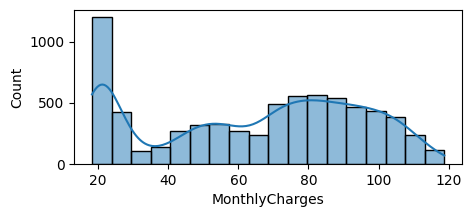

In [73]:
# If numeric check the distribution
# histogram
plt.figure(figsize=(5,2))
sns.histplot(data,x='MonthlyCharges',kde=True)
plt.show()

In [74]:
# Find skew
# skew = [-0.5,0.5]---> normal
# skew > 0.5 --> right skew
# skew <-0.5 --->left skew
data.loc[:,'MonthlyCharges'].skew()

np.float64(-0.22028439456532767)

Since skewness is within [-0.5,0.5] the distribution of MonthlyCharges is normal. We have to replace missing value with mean.

In [75]:
# find mean
data.loc[:,'MonthlyCharges'].mean()

np.float64(64.74958102542253)

In [76]:
# replace with mean
data.loc[:,'MonthlyCharges'] = data.loc[:,'MonthlyCharges'].fillna(data.loc[:,'MonthlyCharges'].mean())

In [77]:
data.loc[:,'MonthlyCharges'].isnull().sum()

np.int64(0)

**TotalCharges**

In [78]:
# check the data type
data.loc[:,'TotalCharges'].dtypes

dtype('O')

Since data type of **Total charges** is object though it has a numeric values. We have to do typecasting to convert object to float64.

1. **astype** : Used to convert one data type into other if column has **no missing values**.
2. **pd.to_numeric** : Used to convert data type of column into other data type  when **there are missing values** in data

In [79]:
# Type casting: converting one data type to other
data.loc[:,'Total_Charges'] = pd.to_numeric(data.loc[:,'TotalCharges'],errors='coerce')
# coerce : converts empty string to null/nan

In [80]:
data.loc[:,'Total_Charges'].dtypes

dtype('float64')

In [81]:
# drop the old column
data.drop(columns='TotalCharges',inplace=True)

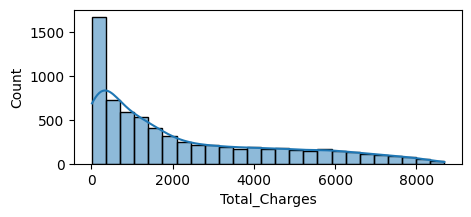

In [82]:
# check distribution
plt.figure(figsize=(5,2))
sns.histplot(data,x='Total_Charges',kde=True)
plt.show()

In [83]:
# find skew
data.loc[:,'Total_Charges'].skew()

np.float64(0.9616058347613503)

In [84]:
# clearly skewness is greater than 0.5 , the distribution is right skewed
# find median
data.loc[:,'Total_Charges'].median()

1397.3

In [85]:
# fill with median
data.loc[:,'Total_Charges']=data.loc[:,'Total_Charges'].fillna(data.loc[:,'Total_Charges'].median())

In [86]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


**5. Remove Duplicates**

In [87]:
data.duplicated().sum()

np.int64(0)

**6. Univariate Analysis**

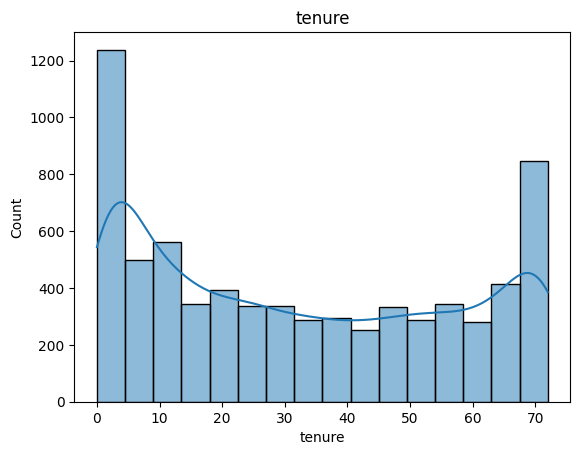

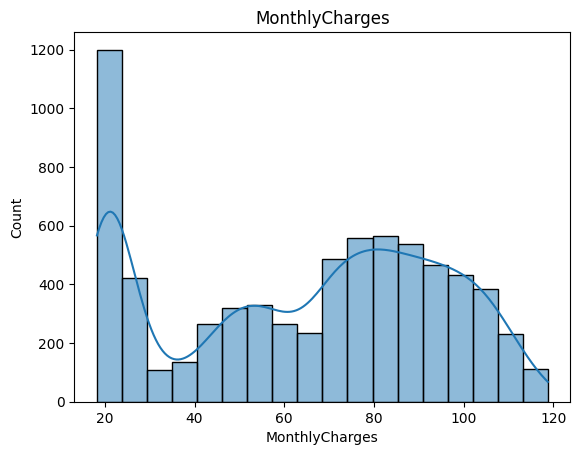

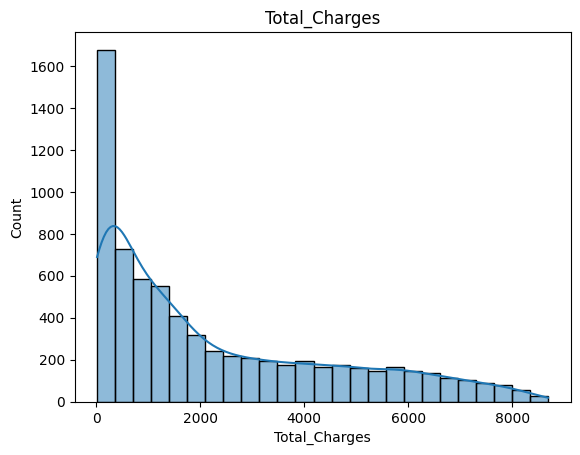

In [88]:
#Distribution of Numerical Features
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical Features
sns.histplot(data['tenure'], kde=True)
plt.title("tenure")
plt.show()

sns.histplot(data['MonthlyCharges'], kde=True)
plt.title("MonthlyCharges")
plt.show()

sns.histplot(data['Total_Charges'], kde=True)
plt.title("Total_Charges")
plt.show()

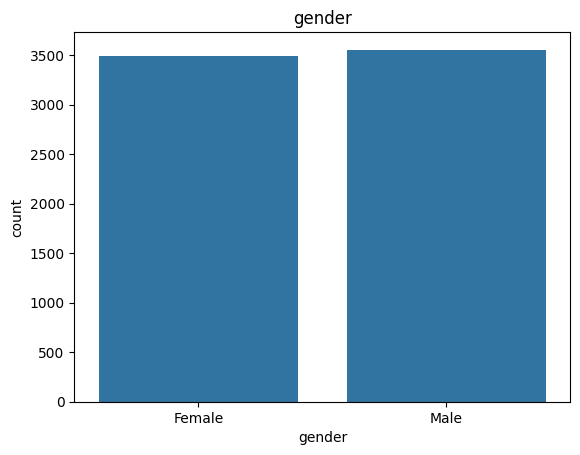

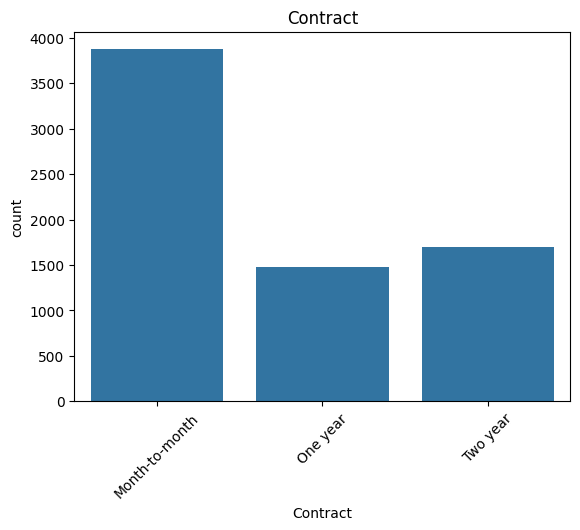

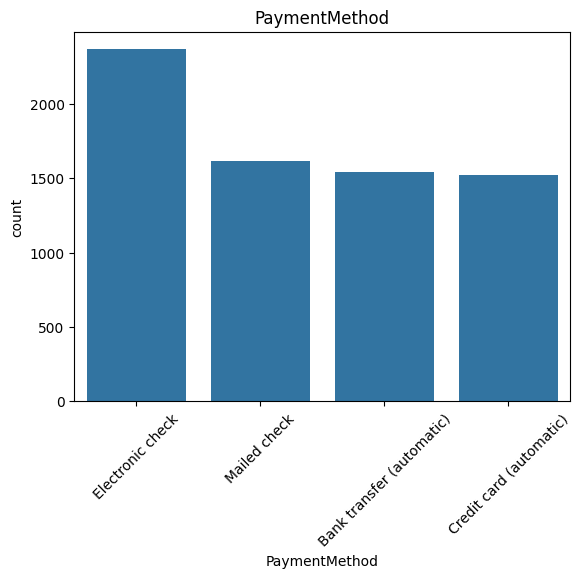

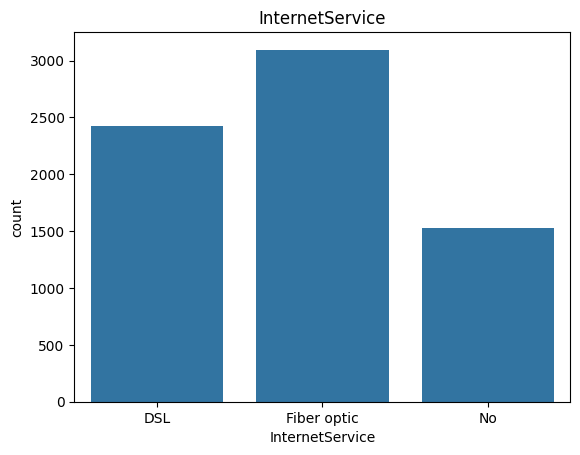

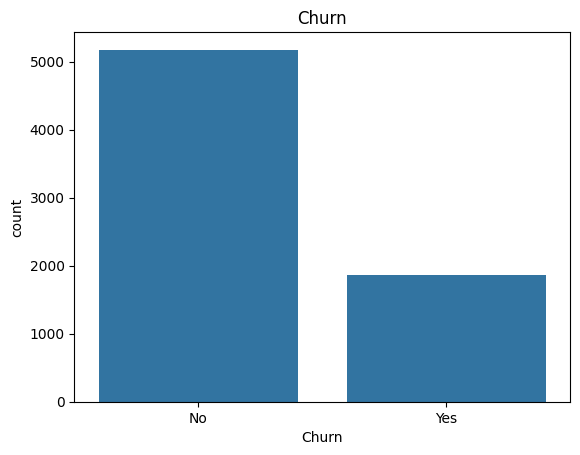

In [89]:
#Count Plots for Categorical Features
sns.countplot(x=data['gender'])
plt.title("gender")
plt.show()

sns.countplot(x=data['Contract'])
plt.title("Contract")
plt.xticks(rotation=45)
plt.show()

sns.countplot(x=data['PaymentMethod'])
plt.title("PaymentMethod")
plt.xticks(rotation=45)
plt.show()

sns.countplot(x=data['InternetService'])
plt.title("InternetService")
plt.show()

sns.countplot(x=data['Churn'])
plt.title("Churn")
plt.show()

**7.7. Bivariate Analysis**

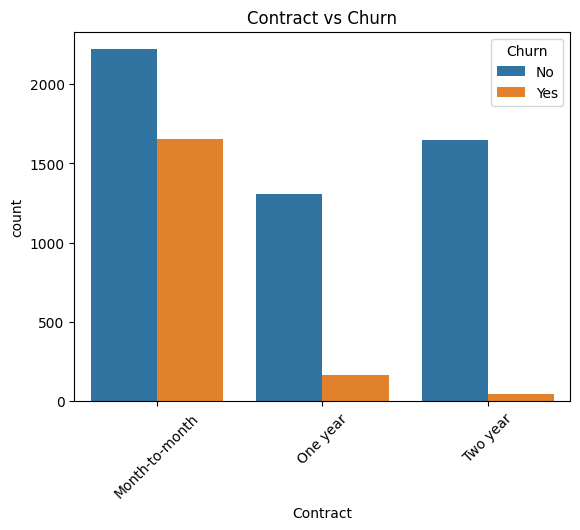

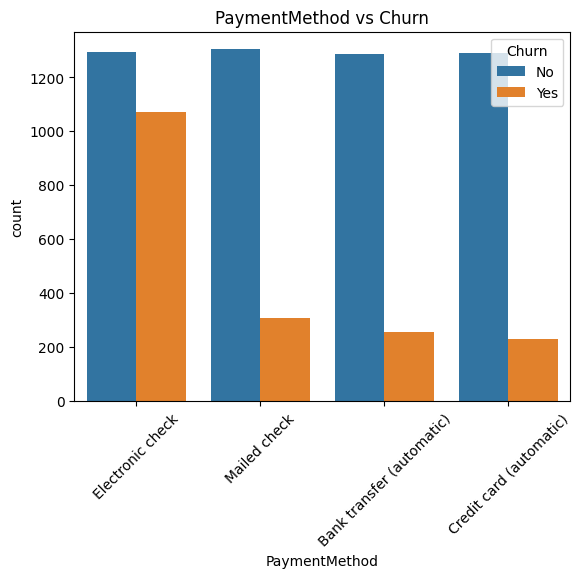

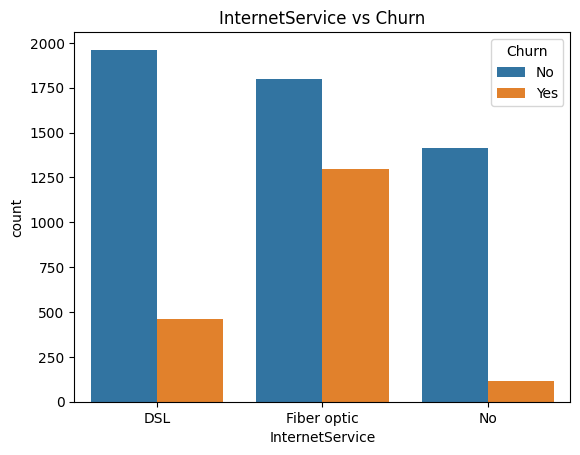

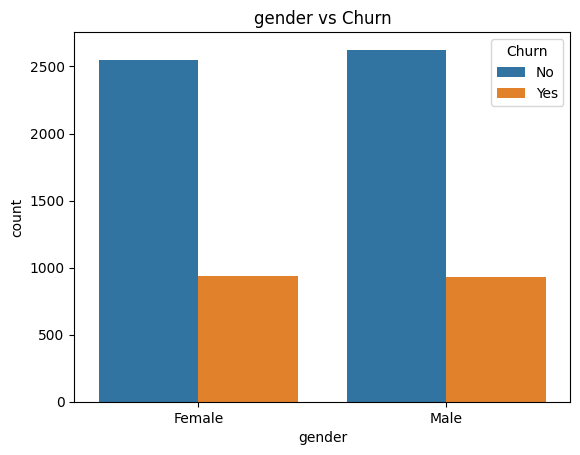

In [90]:
#7. Perform Bivariate Analysis
#Churn vs Categorical Features
sns.countplot(x='Contract', hue='Churn', data=data)
plt.title("Contract vs Churn")
plt.xticks(rotation=45)
plt.show()

sns.countplot(x='PaymentMethod', hue='Churn', data=data)
plt.title("PaymentMethod vs Churn")
plt.xticks(rotation=45)
plt.show()

sns.countplot(x='InternetService', hue='Churn', data=data)
plt.title("InternetService vs Churn")
plt.show()

sns.countplot(x='gender', hue='Churn', data=data)
plt.title("gender vs Churn")
plt.show()

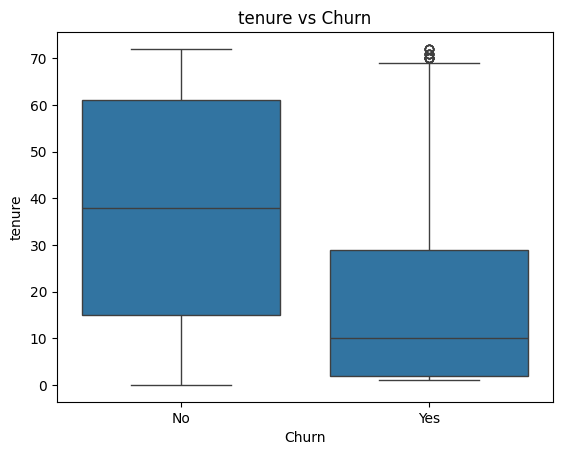

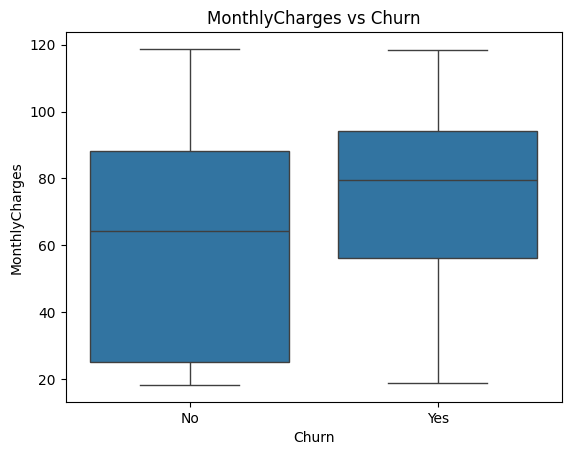

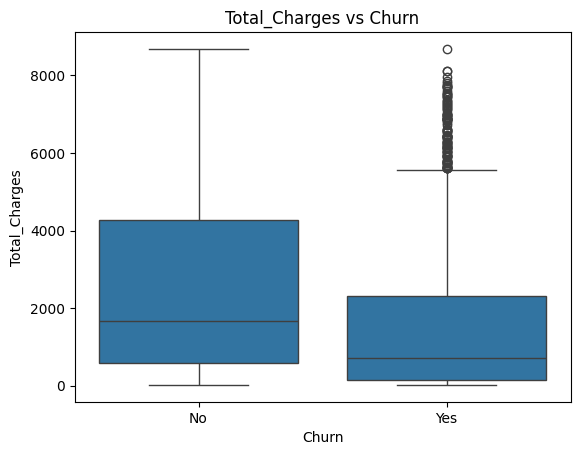

In [91]:
#Numerical vs Categorical (Churn vs Numerical)
sns.boxplot(x='Churn', y='tenure', data=data)
plt.title("tenure vs Churn")
plt.show()

sns.boxplot(x='Churn', y='MonthlyCharges', data=data)
plt.title("MonthlyCharges vs Churn")
plt.show()

sns.boxplot(x='Churn', y='Total_Charges', data=data)
plt.title("Total_Charges vs Churn")
plt.show()

**8. Generate Correlation Heatmap**

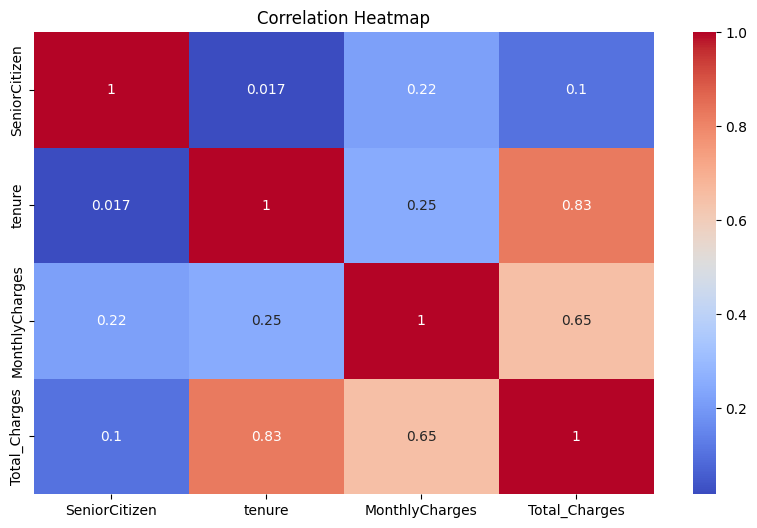

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = data.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**9. Outlier Detection**

In [93]:
num_cols = data.select_dtypes(include=['number']).columns
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'Total_Charges'], dtype='object')

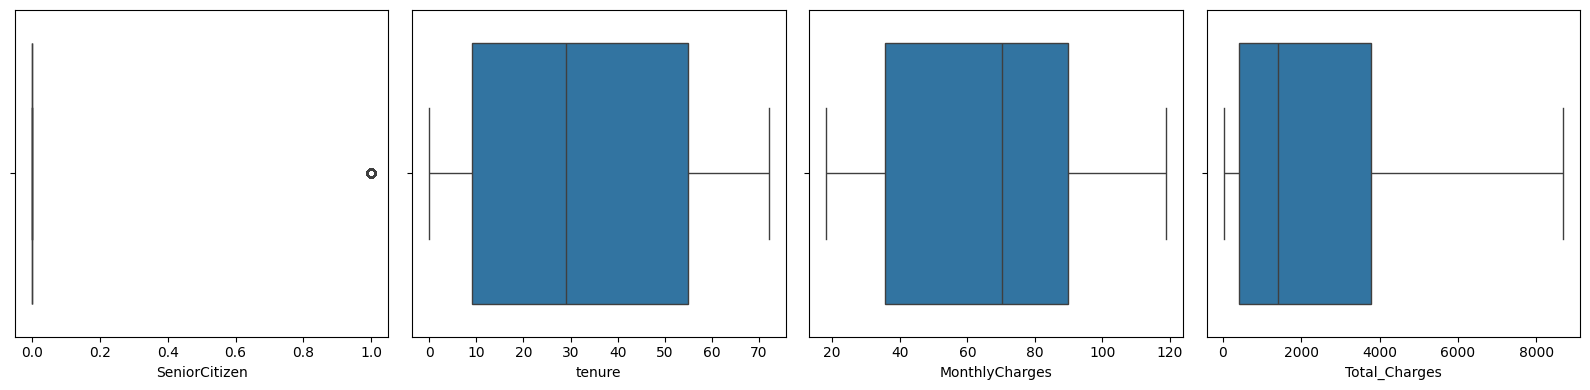

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 4, figsize=(16, 4))

sns.boxplot(data=data, x='SeniorCitizen', ax=ax[0])
sns.boxplot(data=data, x='tenure', ax=ax[1])
sns.boxplot(data=data, x='MonthlyCharges', ax=ax[2])
sns.boxplot(data=data, x='Total_Charges', ax=ax[3])

plt.tight_layout()
plt.show()

outliners are clearly seen in SeniorCitizen

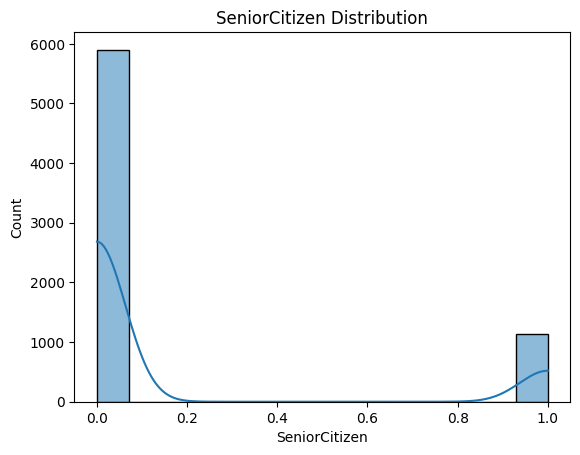

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data, x='SeniorCitizen', kde=True)
plt.title("SeniorCitizen Distribution")
plt.show()

In [96]:
print('SeniorCitizen -->', data['SeniorCitizen'].skew())

SeniorCitizen --> 1.8336327440928564


outlier is right skew

SeniorCitizen

In [97]:
Q1 = data.loc[:,'SeniorCitizen'].quantile(0.25)
Q3 = data.loc[:,'SeniorCitizen'].quantile(0.75)
IQR = Q3-Q1
lower_limit= Q1 - 1.5 * IQR
upper_limit= Q3 + 1.5*IQR

In [98]:
data[(data.loc[:,'SeniorCitizen']>upper_limit)|(data.loc[:,'SeniorCitizen']<lower_limit)]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,Total_Charges
20,8779-QRDMV,Male,1,No,No,1,No,No phone service,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,Yes,39.65
30,3841-NFECX,Female,1,Yes,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,No,No,Two year,Yes,Credit card (automatic),96.35,No,6766.95
31,4929-XIHVW,Male,1,Yes,No,2,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),95.50,No,181.65
34,3413-BMNZE,Male,1,No,No,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Bank transfer (automatic),45.25,No,45.25
50,8012-SOUDQ,Female,1,No,No,43,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,90.25,No,3838.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7023,1035-IPQPU,Female,1,Yes,No,63,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,103.50,No,6479.40
7029,2235-DWLJU,Female,1,No,No,6,No,No phone service,DSL,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,44.40,No,263.05
7031,3605-JISKB,Male,1,Yes,No,55,Yes,Yes,DSL,Yes,...,No,No,No,No,One year,No,Credit card (automatic),60.00,No,3316.10
7032,6894-LFHLY,Male,1,No,No,1,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,75.75,Yes,75.75


In [99]:
len(data[(data.loc[:,'SeniorCitizen']>upper_limit)|(data.loc[:,'SeniorCitizen']<lower_limit)])/len(data)*100


16.21468124378816

Since % of outliers is more than 5% will leave them as it is.

**10. Encoding**

In [100]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['gender'] = le.fit_transform(data['gender'])
data['Partner'] = le.fit_transform(data['Partner'])
data['Dependents'] = le.fit_transform(data['Dependents'])
data['PhoneService'] = le.fit_transform(data['PhoneService'])
data['PaperlessBilling'] = le.fit_transform(data['PaperlessBilling'])
data['Churn'] = le.fit_transform(data['Churn'])

data = pd.get_dummies(data, columns=[
    'Contract',
    'PaymentMethod',
    'InternetService'
], drop_first=True)

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,MonthlyCharges,Churn,Total_Charges,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No
0,7590-VHVEG,0,0,1,0,1,0,No phone service,No,Yes,...,29.85,0,29.85,False,False,False,True,False,False,False
1,5575-GNVDE,1,0,0,0,34,1,No,Yes,No,...,56.95,0,1889.50,True,False,False,False,True,False,False
2,3668-QPYBK,1,0,0,0,2,1,No,Yes,Yes,...,53.85,1,108.15,False,False,False,False,True,False,False
3,7795-CFOCW,1,0,0,0,45,0,No phone service,Yes,No,...,42.30,0,1840.75,True,False,False,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,No,No,No,...,70.70,1,151.65,False,False,False,True,False,True,False


In [101]:
# Drop ID column
data.drop('customerID', axis=1, inplace=True)

# Convert all categorical columns to numeric
data = pd.get_dummies(data, drop_first=True)

**11.Apply Scaling**

In [102]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Select numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'Total_Charges']

data[num_cols] = scaler.fit_transform(data[num_cols])

**12. Separate Features and Target Variable**

In [103]:
X = data.drop('Churn', axis=1)
y = data['Churn']

**13. Perform Train-Test Split**

In [104]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**14. Balance data : SMOTE**

In [105]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state=42)
x_sampled,y_sampled = smote.fit_resample(x_train,y_train)


**15. Train Classification Models**

● Logistic Regression

● K-Nearest Neighbors (KNN)

● Decision Tree Classifier

● Random Forest Classifier

● Support Vector Classifier (SVC)

● Gradient Boosting Classifier

● XGBoost Classifier

In [106]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

log_model = LogisticRegression().fit(x_train, y_train)
knn_model = KNeighborsClassifier().fit(x_train, y_train)
dt_model = DecisionTreeClassifier().fit(x_train, y_train)
rf_model = RandomForestClassifier().fit(x_train, y_train)
svc_model = SVC(probability=True).fit(x_train, y_train)
gb_model = GradientBoostingClassifier().fit(x_train, y_train)
xgb_model = XGBClassifier().fit(x_train, y_train)

**16. Evaluate Models Using**

● Accuracy

● Precision

● Recall

● F1 Score

● ROC-AUC Score

● Confusion Matrix

In [107]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Logistic Regression
y_pred = log_model.predict(x_test)
print("\nLogistic Regression")
print("confusion matrix\n", confusion_matrix(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("f1_score: ", f1_score(y_test, y_pred))
print("roc_auc: ", roc_auc_score(y_test, y_pred))

# KNN
y_pred = knn_model.predict(x_test)
print("\nKNN")
print("confusion matrix\n", confusion_matrix(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("f1_score: ", f1_score(y_test, y_pred))
print("roc_auc: ", roc_auc_score(y_test, y_pred))

# Decision Tree
y_pred = dt_model.predict(x_test)
print("\nDecision Tree")
print("confusion matrix\n", confusion_matrix(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("f1_score: ", f1_score(y_test, y_pred))
print("roc_auc: ", roc_auc_score(y_test, y_pred))

# Random Forest
y_pred = rf_model.predict(x_test)
print("\nRandom Forest")
print("confusion matrix\n", confusion_matrix(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("f1_score: ", f1_score(y_test, y_pred))
print("roc_auc: ", roc_auc_score(y_test, y_pred))

# SVC
y_pred = svc_model.predict(x_test)
print("\nSVC")
print("confusion matrix\n", confusion_matrix(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("f1_score: ", f1_score(y_test, y_pred))
print("roc_auc: ", roc_auc_score(y_test, y_pred))

# Gradient Boosting
y_pred = gb_model.predict(x_test)
print("\nGradient Boosting")
print("confusion matrix\n", confusion_matrix(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("f1_score: ", f1_score(y_test, y_pred))
print("roc_auc: ", roc_auc_score(y_test, y_pred))

# XGBoost
y_pred = xgb_model.predict(x_test)
print("\nXGBoost")
print("confusion matrix\n", confusion_matrix(y_test, y_pred))
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("f1_score: ", f1_score(y_test, y_pred))
print("roc_auc: ", roc_auc_score(y_test, y_pred))


Logistic Regression
confusion matrix
 [[935 101]
 [150 223]]
Accuracy:  0.8218594748048261
Recall:  0.5978552278820375
Precision:  0.6882716049382716
f1_score:  0.6398852223816356
roc_auc:  0.750182440195845

KNN
confusion matrix
 [[893 143]
 [177 196]]
Accuracy:  0.772888573456352
Recall:  0.5254691689008043
Precision:  0.5781710914454278
f1_score:  0.550561797752809
roc_auc:  0.6937191404349581

Decision Tree
confusion matrix
 [[822 214]
 [200 173]]
Accuracy:  0.7061745919091554
Recall:  0.46380697050938335
Precision:  0.4470284237726098
f1_score:  0.45526315789473687
roc_auc:  0.6286216319728384

Random Forest
confusion matrix
 [[945  91]
 [203 170]]
Accuracy:  0.7913413768630234
Recall:  0.45576407506702415
Precision:  0.6513409961685823
f1_score:  0.5362776025236593
roc_auc:  0.6839631186145931

SVC
confusion matrix
 [[952  84]
 [180 193]]
Accuracy:  0.8126330731014905
Recall:  0.517426273458445
Precision:  0.6967509025270758
f1_score:  0.5938461538461538
roc_auc:  0.718172596188

In [108]:
# IMPORT LIBRARIES

from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier



# MODEL INITIALIZATION (WITH HYPERPARAMETERS)

log_model = LogisticRegression(max_iter=1000)

knn_model = KNeighborsClassifier(n_neighbors=5)

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=50,
    max_features='sqrt',
    splitter='best',
    min_samples_leaf=5,
    min_samples_split=6
)

rf_model = RandomForestClassifier(
    n_estimators=10,
    max_depth=50,
    bootstrap=True,
    criterion='gini',
    max_features='sqrt',
    min_samples_split=6,
    min_samples_leaf=5
)

svc_model = SVC(probability=True)

gb_model = GradientBoostingClassifier(
    n_estimators=10,
    learning_rate=0.01,
    max_depth=3
)

xgb_model = XGBClassifier(
    n_estimators=50,
    max_depth=10,
    learning_rate=0.1,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='logloss'
)



# TRAIN MODELS

models = {
    "Logistic Regression": log_model,
    "KNN": knn_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "SVC": svc_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

for name, model in models.items():
    model.fit(x_train, y_train)   # Use SAME dataset for all models





# MODEL EVALUATION


for name, model in models.items():
    y_pred = model.predict(x_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_test)[:, 1]
    else:  # For SVC or models without predict_proba
        y_prob = model.decision_function(x_test)

    print(f"\n================ {name} ================")
    print("Accuracy       :", accuracy_score(y_test, y_pred))
    print("Precision      :", precision_score(y_test, y_pred))
    print("Recall         :", recall_score(y_test, y_pred))
    print("F1 Score       :", f1_score(y_test, y_pred))
    print("ROC-AUC Score  :", roc_auc_score(y_test, y_prob))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:12:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



================ Logistic Regression ================
Accuracy       : 0.8218594748048261
Precision      : 0.6882716049382716
Recall         : 0.5978552278820375
F1 Score       : 0.6398852223816356
ROC-AUC Score  : 0.8623223472419184
Confusion Matrix:
 [[935 101]
 [150 223]]

================ KNN ================
Accuracy       : 0.772888573456352
Precision      : 0.5781710914454278
Recall         : 0.5254691689008043
F1 Score       : 0.550561797752809
ROC-AUC Score  : 0.7974965582204189
Confusion Matrix:
 [[893 143]
 [177 196]]

================ Decision Tree ================
Accuracy       : 0.7913413768630234
Precision      : 0.632996632996633
Recall         : 0.5040214477211796
F1 Score       : 0.5611940298507463
ROC-AUC Score  : 0.8018505387808337
Confusion Matrix:
 [[927 109]
 [185 188]]

================ Random Forest ================
Accuracy       : 0.8097941802696949
Precision      : 0.6842105263157895
Recall         : 0.5227882037533512
F1 Score       : 0.5927051671732523
R

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**17. Apply Hyperparameter Tuning**

● GridSearchCV

● RandomizedSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# 🔹 GridSearchCV (Random Forest)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(x_train, y_train)

print("\nRandom Forest GridSearch")
print("Best Parameters:", grid.best_params_)

rf_best = grid.best_estimator_
y_pred = rf_best.predict(x_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("f1_score: ", f1_score(y_test, y_pred))


# 🔹 RandomizedSearchCV (XGBoost)
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

random = RandomizedSearchCV(XGBClassifier(), param_dist, cv=5, scoring='accuracy', n_iter=5)
random.fit(x_train, y_train)

print("\nXGBoost RandomizedSearch")
print("Best Parameters:", random.best_params_)

xgb_best = random.best_estimator_
y_pred = xgb_best.predict(x_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("f1_score: ", f1_score(y_test, y_pred))

**18. Compare Model Performance**

● Create comparison table

● Identify best model

In [ ]:
import pandas as pd

# Initialize empty list to store results
results = []

for name, model in models.items():
    y_pred = model.predict(x_test)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(x_test)[:, 1]
    else:  # For SVC
        y_prob = model.decision_function(x_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Sort by desired metric (e.g., ROC-AUC or F1 Score)
results_df = results_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

# Display comparison table
print(results_df)

**Best Model:Logistic Regression**

# 19. Select Best Model

## 1️ Best Model Based on Metrics

| Model               | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|--------------------|---------|-----------|--------|----------|---------|
| Logistic Regression | 0.822   | 0.688     | 0.598  | 0.640    | 0.862   |
| Random Forest       | 0.805   | 0.668     | 0.523  | 0.586    | 0.847   |
| XGBoost             | 0.791   | 0.633     | 0.499  | 0.558    | 0.843   |
| SVC                 | 0.813   | 0.697     | 0.517  | 0.594    | 0.808   |

** Best Model:** **Logistic Regression**  

**Reason:**  
- Highest **ROC-AUC (0.862)** → best at distinguishing classes.  
- Balanced **Precision (0.688)** and **Recall (0.598)** → good trade-off between correctly predicting positives and capturing most positive cases.  
- Highest **F1 Score (0.640)** → balanced performance.  

**Runner-up:** Random Forest (slightly lower metrics, can handle non-linear patterns better).  

---

## 2️ Business Interpretation

- The model can reliably predict **positive cases** (e.g., customers likely to churn, employees likely to leave).  
- **Precision (0.688):** When the model predicts “will churn,” it is correct ~69% of the time → prevents unnecessary interventions.  
- **Recall (0.598):** Captures ~60% of actual positive cases → reduces the risk of missing high-risk cases.  
- **ROC-AUC (0.862):** Model confidently separates positives from negatives → overall strong performance.  

**Business Use Case:**  
1. Targeted interventions (emails, offers, HR engagement) can be focused on predicted high-risk individuals.  
2. Logistic Regression allows **feature interpretation**, helping to understand **key drivers of churn/attrition**.  
3. Decision-makers can prioritize strategies based on **predicted risk scores** rather than treating all cases equally.  

**Conclusion:**  
- **Logistic Regression is selected as the best model** for this problem due to its **accuracy, interpretability, and balanced performance across metrics**.

# 20. Final Insights

##  Key Factors Influencing Churn
- **High Monthly Charges** → Customers with higher bills are more likely to churn.  
- **Month-to-Month Contracts** → Short-term contracts increase churn risk.  
- **No Tech Support** → Lack of support leads to dissatisfaction and higher churn.  
- **Short Tenure** → Customers with shorter tenure are more likely to leave.

---

##  Business Recommendations
- **Offer long-term contract discounts** → Encourage customers to commit for longer periods.  
- **Improve customer support services** → Reduce churn by addressing complaints proactively.  
- **Provide personalized retention offers** → Tailor incentives to at-risk customers.  
- **Identify high-risk customers early** → Use model predictions to act before churn occurs.  
- **Reduce churn through loyalty programs** → Reward and retain valuable customers.

---

**Conclusion:**  
By focusing on these key factors and implementing targeted strategies, the business can **reduce churn, improve customer satisfaction, and increase revenue stability**.